# 05 — Recommender Embeddings with Matrix Factorization

This notebook uses unsupervised matrix factorization to learn user and item embeddings from implicit interactions.


In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.append(str(Path.cwd() / "src"))

from unsup_lab.data import make_user_item_interactions
from unsup_lab.plotting import plot_embedding
from unsup_lab.recommenders import (
    build_sparse_interactions,
    discover_item_groups,
    factorize_interactions,
    recommend_for_user,
    similar_items,
)

In [2]:
interactions, dense_matrix = make_user_item_interactions(
    n_users=600,
    n_items=120,
    n_latent_groups=5,
    random_state=42,
)

# Rebuild the interaction matrix in sparse form from the long-form log,
# which is how it would arrive from an event store in practice.
matrix = build_sparse_interactions(interactions, n_users=600, n_items=120)
print(f"sparse shape: {matrix.shape}, stored entries: {matrix.nnz}")
interactions.head()

sparse shape: (600, 120), stored entries: 7378


,user_id,item_id,interaction_strength
0,0,19,0.578624
1,0,22,1.588311
2,0,25,1.967305
3,0,44,4.015333
4,0,49,1.143618


## Learn latent factors

In [3]:
factors = factorize_interactions(matrix, n_components=12, method="svd", random_state=42)
user_factors = factors.user_factors
item_factors = factors.item_factors

print(user_factors.shape)
print(item_factors.shape)

(600, 12)
(120, 12)


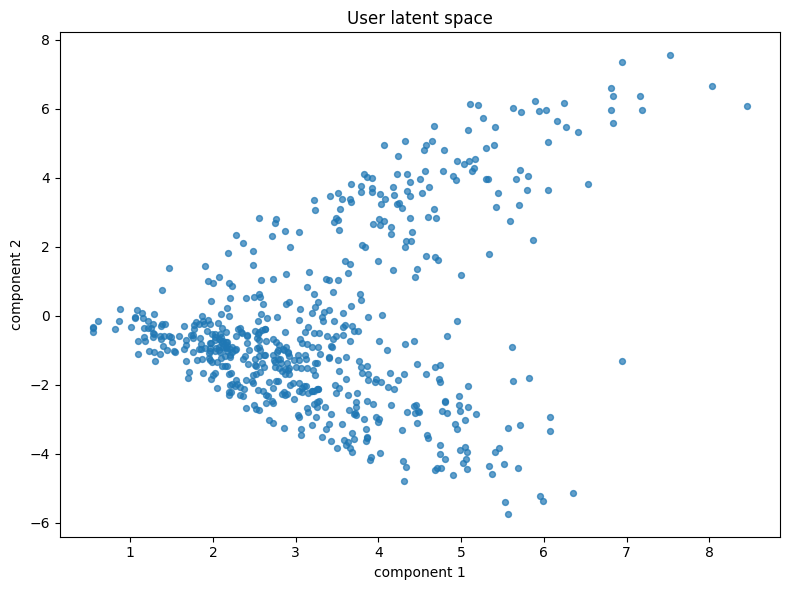

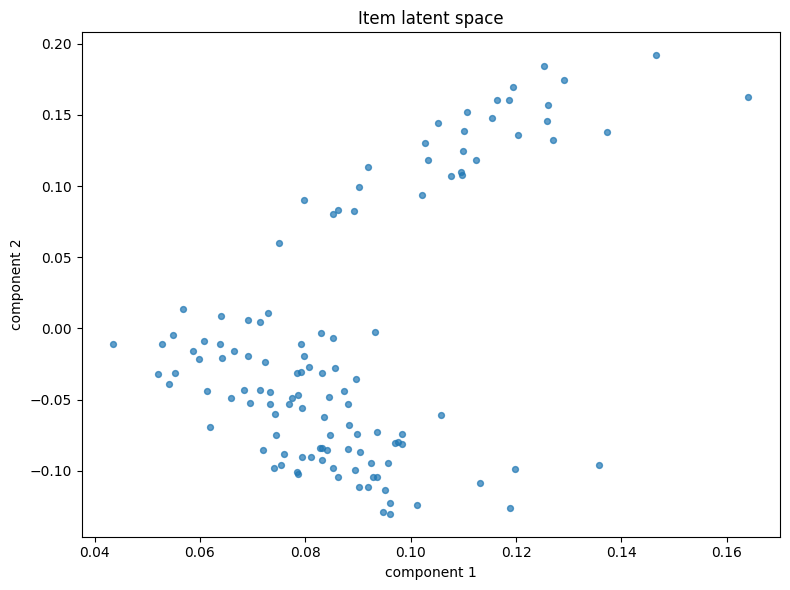

In [4]:
plot_embedding(user_factors[:, :2], title="User latent space")
plot_embedding(item_factors[:, :2], title="Item latent space")

## Similar item search

In [5]:
query_item = 3
neighbours = similar_items(item_factors, query_item, k=10)

pd.DataFrame(neighbours, columns=["similar_item", "cosine_similarity"]).assign(
    query_item=query_item
)

,similar_item,cosine_similarity,query_item
0,98,0.883088,3
1,103,0.784357,3
2,94,0.782832,3
3,58,0.728753,3
4,77,0.676912,3
5,102,0.645525,3
6,22,0.637284,3
7,34,0.632535,3
8,99,0.579728,3
9,19,0.575356,3


## Product group discovery

Clustering the item embeddings groups products that are co-consumed, which is a useful unsupervised proxy for catalogue structure.

In [6]:
item_groups = discover_item_groups(item_factors, n_groups=5, random_state=42)
pd.Series(item_groups).value_counts().sort_index().rename("n_items").to_frame()

,n_items
0,20
1,21
2,18
3,31
4,30


## Recommendations and cold start

Reconstructed scores rank items a user has not yet touched. New users or items with no interactions have no row or column signal, so the model cannot place them - the classic cold-start problem, which needs content features or popularity fallbacks rather than factorisation alone.

In [7]:
user_id = 0
recommendations = recommend_for_user(factors, matrix, user_id, k=10)
pd.DataFrame(recommendations, columns=["item_id", "score"]).assign(user_id=user_id)

,item_id,score,user_id
0,104,1.387530,0
1,106,0.910786,0
2,84,0.867408,0
3,3,0.803066,0
4,57,0.675673,0
5,14,0.577278,0
6,99,0.547703,0
7,103,0.514707,0
8,111,0.514208,0
9,15,0.505062,0


## Limitations

Matrix factorization can reveal useful latent structure, but it can also amplify exposure bias. Implicit feedback is not the same as preference.
